#Drone-based Pollution Cleanup Optimization
Analysis of Algorithms Course Project

Kira Cibak

4/26/2025

#Introduction
This notebook analyzes and optimizes the selection of cleaning hotspots based on priority, cleaning effort, and energy constraints. The objective is to develop an efficient algorithm that selects the best hotspots to clean while minimizing energy usage and maximizing the priority score.

There are a few different approaches, including brute-force and optimized solutions, with an evaluation of their time complexities. There are visualizations of execution time as a function of input size to understand how the algorithm scales.

In [1]:
# Problem Dataset (100 Hotspots)

hotspots = [(1, 90, 40, 20), (2, 70, 30, 10), (3, 120, 80, 25), (4, 60, 20, 30), (5, 100, 50, 15),
            (6, 80, 60, 20), (7, 150, 70, 30), (8, 50, 25, 10), (9, 110, 55, 18), (10, 95, 45, 22),
            (11, 85, 35, 12), (12, 130, 90, 28), (13, 75, 40, 16), (14, 105, 60, 24), (15, 65, 30, 14),
            (16, 115, 70, 26), (17, 55, 20, 8), (18, 140, 85, 32), (19, 100, 50, 20), (20, 125, 75, 30),
            (21, 80, 50, 14), (22, 68, 38, 1), (23, 114, 74, 18), (24, 67, 27, 22), (25, 94, 50, 15),
            (26, 78, 70, 11), (27, 156, 77, 38), (28, 52, 19, 0), (29, 116, 64, 17), (30, 104, 52, 28),
            (31, 91, 35, 3), (32, 138, 98, 36), (33, 78, 30, 18), (34, 108, 50, 29), (35, 58, 39, 9),
            (36, 113, 78, 30), (37, 63, 21, 0), (38, 148, 83, 42), (39, 108, 43, 15), (40, 117, 70, 24),
            (41, 90, 48, 13), (42, 71, 39, 17), (43, 112, 90, 21), (44, 65, 28, 35), (45, 101, 50, 5),
            (46, 71, 57, 17), (47, 148, 78, 21), (48, 50, 24, 3), (49, 109, 52, 27), (50, 91, 49, 16),
            (51, 91, 35, 17), (52, 135, 87, 31), (53, 72, 34, 23), (54, 114, 50, 27), (55, 62, 38, 6),
            (56, 111, 69, 19), (57, 61, 24, 2), (58, 131, 92, 23), (59, 92, 56, 24), (60, 117, 85, 22),
            (61, 80, 36, 23), (62, 79, 36, 3), (63, 129, 71, 26), (64, 56, 16, 28), (65, 109, 59, 12),
            (66, 88, 53, 21), (67, 140, 72, 35), (68, 54, 24, 2), (69, 110, 50, 16), (70, 101, 41, 24),
            (71, 86, 35, 2), (72, 120, 86, 29), (73, 67, 45, 13), (74, 111, 70, 25), (75, 60, 27, 15),
            (76, 106, 74, 25), (77, 58, 23, 1), (78, 131, 78, 42), (79, 93, 50, 14), (80, 127, 72, 21),
            (81, 97, 40, 13), (82, 75, 20, 3), (83, 120, 81, 27), (84, 66, 25, 32), (85, 106, 45, 14),
            (86, 79, 70, 29), (87, 153, 77, 32), (88, 46, 31, 11), (89, 109, 54, 10), (90, 93, 49, 29),
            (91, 77, 32, 3), (92, 122, 85, 25), (93, 76, 49, 8), (94, 115, 52, 20), (95, 75, 36, 23),
            (96, 108, 70, 19), (97, 60, 16, 15), (98, 134, 92, 38), (99, 108, 51, 14), (100, 123, 65, 33)]


battery_capacity = 1000

#a) Brute Force Approach

The brute force method iterates over every possible combination of hotspots (i.e. every subset) and for each one, simulates the mission. For every hotspot visited, the drone must:

Spend energy equal to its round-trip travel cost.

Spend additional energy to clean the hotspot.

Because the drone can partially clean a hotspot, if the available battery (after paying travel cost) is less than the cleaning effort, then the drone cleans as much as possible (earning a proportional fraction of the hotspot’s priority).

##PSEUDOCODE


function brute_max_priority(hotspots, battery_capacity, max_subset_size, timeout):

    start_time = current_time()
    best_score = 0
    best_plan = []

    # Iterate over subset sizes from 1 to max_subset_size
    for subset_size in range(1, min(max_subset_size + 1, total_hotspots + 1)):
        
        # Generate all subsets of given size
        for subset in combinations(hotspots, subset_size):
            
            # Generate all possible orderings (permutations) of the subset
            for route in permutations(subset):

                # Check timeout condition
                if timeout is set and elapsed_time > timeout:
                    return best_score, best_plan

                remaining_batt = battery_capacity
                current_score = 0
                current_plan = []

                # Evaluate the route
                for hotspot in route:
                    (hotspot_id, priority, cleaning, travel) = hotspot

                    # If not enough battery for travel, skip this hotspot
                    if remaining_batt < travel:
                        continue

                    available = remaining_batt - travel
                    
                    # Determine how much cleaning can be performed
                    cleaning_done = min(available, cleaning)

                    # If any cleaning is performed, calculate score
                    if cleaning_done > 0:
                        score = (cleaning_done / cleaning) * priority
                        current_score += score
                        current_plan.append(hotspot_id)
                        
                        # Update remaining battery
                        remaining_batt -= (travel + cleaning_done)

                # Update best solution if current score is higher
                if current_score > best_score:
                    best_score = current_score
                    best_plan = current_plan

    return best_score, best_plan

#b) Brute Force Complexity Analysis

Time:
The time complexity of this implementation is O(n * n!). This results from generating all combinations and permutations of hotspots and then evaluating each permutation.

Space:
The space complexity of this implementation is O(n). This accounts for the current_plan array for each iteration as well as the best_subset array returned at the end of the function.

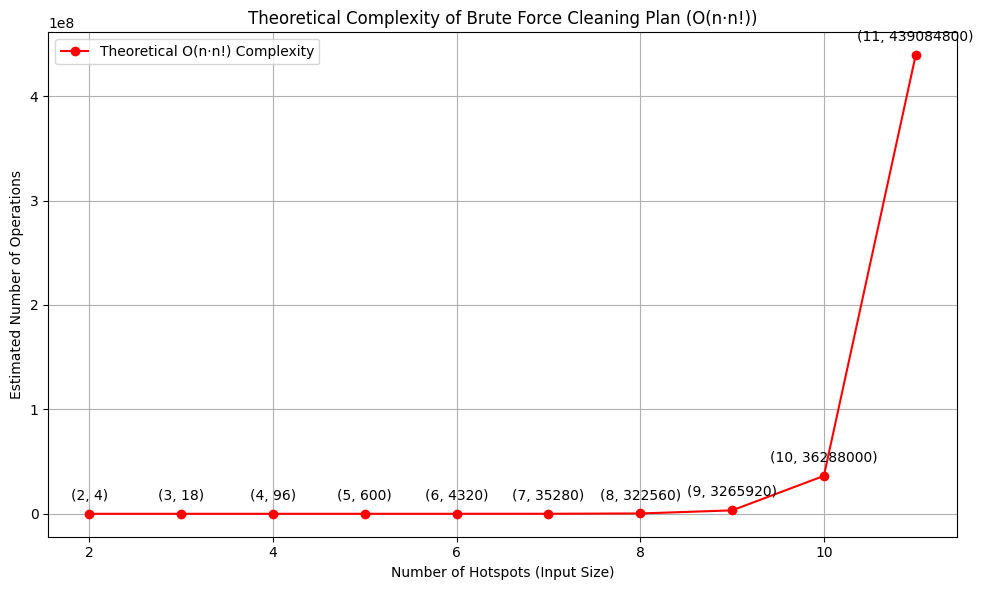

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import math

# Define input sizes (number of hotspots)
input_sizes = np.arange(2, 12)  # From 2 to 11 hotspots

# Compute theoretical complexity: O(n * n!)
theoretical_complexity = [n * math.factorial(n) for n in input_sizes]

plt.figure(figsize=(10,6))
plt.plot(input_sizes, theoretical_complexity, marker='o', linestyle='-', color='r', label='Theoretical O(n·n!) Complexity')

# Add labels for each point
for i, txt in enumerate(theoretical_complexity):
    label = f"({input_sizes[i]}, {txt:.0f})"
    plt.annotate(label,
                 (input_sizes[i], theoretical_complexity[i]),
                 textcoords="offset points",
                 xytext=(0,10),
                 ha='center')

plt.xlabel('Number of Hotspots (Input Size)')
plt.ylabel('Estimated Number of Operations')
plt.title('Theoretical Complexity of Brute Force Cleaning Plan (O(n·n!))')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

This graph illustrates the theoretical complexity of the brute-force approach for planning a cleaning sequence, which follows O(n⋅n!). The curve shows the rapid growth in computational cost as the number of hotspots increases. Even for relatively small input sizes, the factorial component causes an exponential-like escalation in the number of estimated operations. This confirms the impracticality of the brute-force method for large inputs, as each additional hotspot dramatically increases the computational effort required.

#c) Proof of Correctness using loop invariant
##I selected the for loop that traverses the hotspots from my pseudocode.

Initialization:

The loop invariant is that before processing each hotspot, remaining reflects the energy left after cleaning previously chosen hotspots, and current_score reflects the total score achieved.

Maintenance:

For each hotspot, if remaining >= travel_cost, the algorithm computes the maximum cleaning possible. Since the score is computed as a proportional fraction, the invariant holds that the computed score is exactly the score achievable with the available energy.

Termination:

When the loop completes, current_score is the total score for that subset. By comparing across all subsets, the algorithm correctly identifies the maximum possible score.
A formal proof would use induction on the number of hotspots in the subset, showing that at each iteration the decision is optimal given the available energy.

#d) Brute Force Implementation

In [2]:
import itertools
import time

def brute_max_priority(hotspots, battery_capacity, max_subset_size=None, timeout=None):
    """
    Find the best subset of hotspots to maximize priority score using brute force.

    Args:
        hotspots: List of hotspots, each as (id, priority, cleaning_cost, travel_cost)
        battery_capacity: Total available battery
        max_subset_size: Maximum size of subsets to consider (defaults to all hotspots)
        timeout: Optional timeout in seconds

    Returns:
        Tuple of (best_score, best_plan) where plan is list of hotspot IDs
    """
    start_time = time.time()
    if max_subset_size is None:
        max_subset_size = len(hotspots)

    best_score = 0
    best_plan = []

    # Loop through possible subset sizes
    for r in range(1, min(max_subset_size + 1, len(hotspots) + 1)):
        # Generate all possible combinations of hotspots of size r
        for subset in itertools.combinations(hotspots, r):
            # Generate all possible permutations of this subset
            for route in itertools.permutations(subset):
                # Check timeout if specified
                if timeout and time.time() - start_time > timeout:
                    return best_score, best_plan

                remaining_batt = battery_capacity
                curr_score = 0
                curr_plan = []

                # Evaluate each hotspot in the current route
                for hotspot in route:
                    hotspot_id, priority, cleaning, travel = hotspot

                    # Skip if not enough battery to travel
                    if remaining_batt < travel:
                        continue

                    # Calculate available battery after travel
                    available = remaining_batt - travel

                    # Determine cleaning amount based on available battery
                    cleaning_done = min(available, cleaning)

                    # Calculate score contribution
                    if cleaning_done > 0:
                        score = (cleaning_done / cleaning) * priority
                        curr_score += score
                        curr_plan.append(hotspot_id)

                        # Update remaining battery
                        remaining_batt -= (travel + cleaning_done)

                # Update best solution if current is better
                if curr_score > best_score:
                    best_score = curr_score
                    best_plan = curr_plan

    return best_score, best_plan

#e) Brute Force Performance Testing

In [ ]:
import time
import matplotlib.pyplot as plt
import numpy as np

def run_performance_test(hotspots, battery_capacity, sizes_to_test=None, time_limit=300):
    """
    Run performance tests on the brute force algorithm with varying input sizes.

    Args:
        hotspots: Your predefined list of hotspots
        battery_capacity: Your predefined battery capacity
        sizes_to_test: List of input sizes to test (e.g., [2, 3, 4, 5])
        time_limit: Overall time limit in seconds (default: 5 minutes)

    Returns:
        Dictionary with sizes as keys and execution times as values
    """
    if sizes_to_test is None:
        sizes_to_test = [2, 3, 4, 5, 6, 7, 8]  # Default to testing 2-8 hotspots

    size_to_time = {}
    start_time_overall = time.time()

    print("Starting performance tests...")

    for size in sizes_to_test:
        # Check if we still have time
        if time.time() - start_time_overall > time_limit:
            print(f"Time limit of {time_limit} seconds reached. Stopping tests.")
            break

        print(f"Testing with {size} hotspots...")

        # Use the first 'size' hotspots from your list
        test_hotspots = hotspots[:size]

        # Time the execution
        start_time = time.time()
        best_score, best_subset = brute_max_priority(test_hotspots, battery_capacity)
        end_time = time.time()

        execution_time = end_time - start_time
        size_to_time[size] = execution_time

        print(f"  Size {size}: {execution_time:.4f} seconds")
        print(f"  Best score: {best_score}")
        print()

    return size_to_time

def plot_performance(size_to_time):
    """
    Plot the performance data.

    Args:
        size_to_time: Dictionary with sizes as keys and execution times as values
    """
    sizes = list(size_to_time.keys())
    times = list(size_to_time.values())

    plt.figure(figsize=(10, 6))

    # Plot the execution times
    plt.plot(sizes, times, 'o-', color='blue', linewidth=2, markersize=8)

    # Add exponential trendline if enough data points
    if len(sizes) > 2:
        # Fit exponential curve (y = a * b^x)
        x = np.array(sizes)
        y = np.array(times)
        # Take log to linearize
        log_y = np.log(y + 1e-10)  # Add small value to avoid log(0)
        # Linear fit
        coeffs = np.polyfit(x, log_y, 1)
        # Convert back
        a = np.exp(coeffs[1])
        b = np.exp(coeffs[0])

        # Plot trendline
        x_smooth = np.linspace(min(sizes), max(sizes), 100)
        y_smooth = a * b**x_smooth
        plt.plot(x_smooth, y_smooth, '--', color='red',
                label=f'Exponential trend: y = {a:.2e} × {b:.2f}^x')

    # Add labels and title
    plt.xlabel('Number of Hotspots', fontsize=12)
    plt.ylabel('Execution Time (seconds)', fontsize=12)
    plt.title('Brute Force Algorithm Performance', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)

    if len(sizes) > 2:
        plt.legend()

    # Format y-axis with scientific notation for large values
    if max(times) > 1000:
        plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

    plt.tight_layout()
    plt.show()

Starting performance tests...
Testing with 2 hotspots...
  Size 2: 0.0000 seconds
  Best score: 160.0

Testing with 3 hotspots...
  Size 3: 0.0000 seconds
  Best score: 280.0

Testing with 4 hotspots...
  Size 4: 0.0001 seconds
  Best score: 340.0

Testing with 5 hotspots...
  Size 5: 0.0005 seconds
  Best score: 440.0

Testing with 6 hotspots...
  Size 6: 0.0044 seconds
  Best score: 520.0

Testing with 7 hotspots...
  Size 7: 0.0340 seconds
  Best score: 670.0

Testing with 8 hotspots...
  Size 8: 0.3041 seconds
  Best score: 720.0

Testing with 9 hotspots...
  Size 9: 2.9462 seconds
  Best score: 830.0

Testing with 10 hotspots...
  Size 10: 36.5601 seconds
  Best score: 925.0

Testing with 11 hotspots...
  Size 11: 448.0602 seconds
  Best score: 1010.0



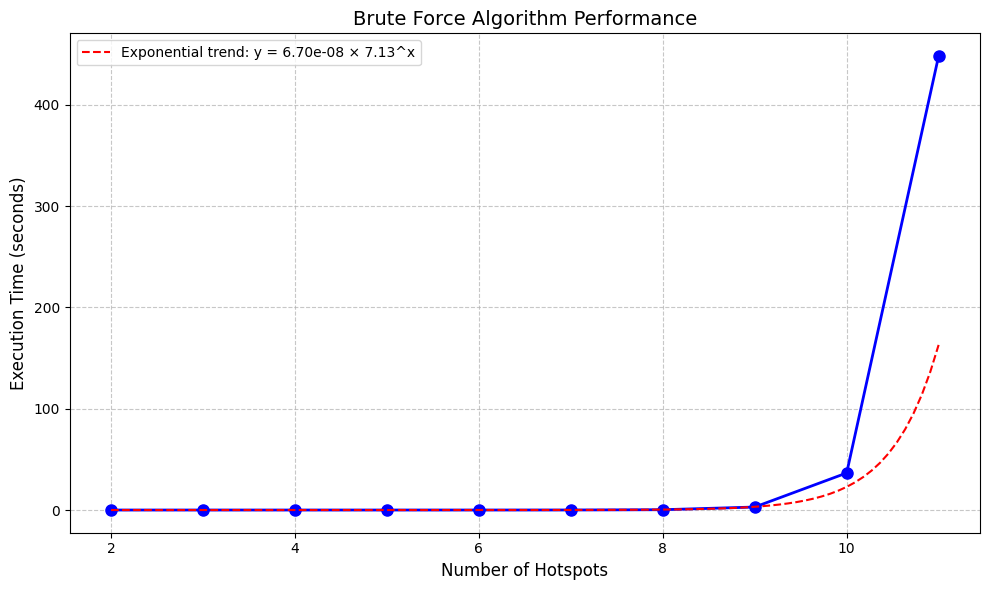

In [ ]:
# Define your test sizes - start small and increase if tests complete quickly
sizes_to_test = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]  # You can extend this based on performance

# Run the performance test
performance_data = run_performance_test(hotspots, battery_capacity, sizes_to_test)

# Plot the results
plot_performance(performance_data)

This performance test shows how the input grows factorially as the input size increases.

#f) Optimal Algorithm - Greedy Approach


This problem can be solved using the following greedy approach:

Selection Procedure:

The algorithm sorts all hotspots in descending order based on the ratio of priority score to cleaning effort. This ensures that the hotspots with the highest priority per unit of cleaning effort are considered first, making the selection process more efficient.


Feasibility Check:

For each hotspot in the sorted list, the algorithm checks whether there is enough remaining battery capacity to reach it. If there isn't enough energy for travel, the hotspot is skipped. Otherwise, the available battery after travel is calculated to determine how much cleaning can be performed.


Solution Check:

As hotspots are selected, the algorithm keeps track of the total score and the cleaning effort allocated to each. The process continues until no more hotspots can be visited without exceeding the battery limit. Finally, the algorithm returns the total priority score achieved and the selected cleaning plan.

##PSEUDOCODE

def greedy_max_priority(hotspots, battery_capacity):
    # Sort hotspots by (priority / cleaning_effort) descending
    sorted_hotspots = sort_by(hotspots, key=lambda h: h.priority / h.cleaning_effort, reverse=True)
    
    remaining = battery_capacity
    total_score = 0
    plan = []
    
    for hotspot in sorted_hotspots:
        if remaining < hotspot.travel_cost:
            continue
            
        available = remaining - hotspot.travel_cost
        cleaning_done = min(available, hotspot.cleaning_effort)
        score = (cleaning_done / hotspot.cleaning_effort) * hotspot.priority
        
        total_score += score
        plan.append((hotspot.id, cleaning_done))
        remaining -= (hotspot.travel_cost + cleaning_done)
        
    return total_score, plan

#g) Greedy Approach Complexity Analysis
Time: The time complexity for this approach would be O(nlogn) due to the sorting used at the beginning of the function.

Space: The space complexity would be O(n) since there is an additional array of size n used for the sorted list and the plan of action array.

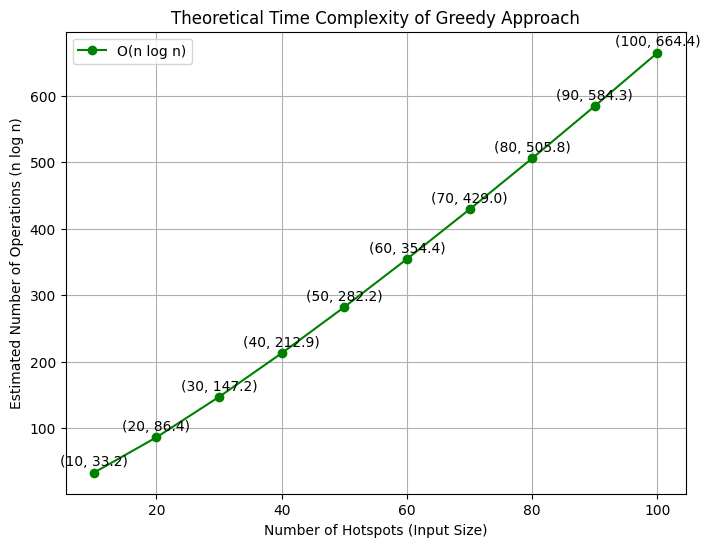

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create a range of input sizes (number of hotspots)
input_sizes = np.arange(10, 110, 10)  # for example, from 10 to 100 hotspots

# Calculate the theoretical number of operations for each input size
theoretical_ops = [n * np.log2(n) for n in input_sizes]

# Plot the theoretical complexity curve
plt.figure(figsize=(8,6))
plt.plot(input_sizes, theoretical_ops, marker='o', linestyle='-', color='g', label='O(n log n)')
for i, op in enumerate(theoretical_ops):
    plt.annotate(f"({input_sizes[i]}, {op:.1f})", (input_sizes[i], op), textcoords="offset points", xytext=(0,5), ha='center')

plt.xlabel('Number of Hotspots (Input Size)')
plt.ylabel('Estimated Number of Operations (n log n)')
plt.title('Theoretical Time Complexity of Greedy Approach')
plt.legend()
plt.grid(True)
plt.show()

This performance test shows that as the input size grows, the time complexity of the algorithm displays logarithmic linear growth.

#h) Greedy Approach Implementation

In [ ]:
def greedy_max_priority(hotspots, battery_capacity):
    """
    Greedy algorithm to maximize priority score.
    Each hotspot is represented as a tuple: (id, priority, cleaning_effort, travel_cost)

    Returns:
        Tuple of (total_score, plan), where plan is a list of selected hotspot IDs.
    """
    # Copy the input list to preserve the original data
    remaining_hotspots = hotspots.copy()

    # Sort hotspots by priority-to-cost ratio in descending order
    sorted_hotspots = sorted(remaining_hotspots, key=lambda x: x[1] / (x[2] + x[3]), reverse=True)

    remaining_battery = battery_capacity
    total_score = 0
    plan = []

    while sorted_hotspots:
        best_hotspot = None
        best_score_gain = 0
        best_index = -1

        # Evaluate each hotspot to find the best option under current battery constraints
        for i, hotspot in enumerate(sorted_hotspots):
            hotspot_id, priority, cleaning, travel = hotspot

            # Skip if battery is insufficient to travel to this hotspot
            if remaining_battery < travel:
                continue

            # Calculate battery available for cleaning after traveling
            available = remaining_battery - travel

            # Determine how much cleaning can be done
            cleaning_done = min(available, cleaning)

            # Compute potential score gain for this hotspot
            if cleaning_done > 0:
                score_gain = (cleaning_done / cleaning) * priority

                # Track the hotspot with the highest score gain
                if score_gain > best_score_gain:
                    best_score_gain = score_gain
                    best_hotspot = hotspot
                    best_index = i

        # If a feasible hotspot was found, allocate resources and update state
        if best_hotspot:
            hotspot_id, priority, cleaning, travel = best_hotspot
            available = remaining_battery - travel
            cleaning_done = min(available, cleaning)

            # Update score and battery usage
            score_gained = (cleaning_done / cleaning) * priority
            total_score += score_gained
            plan.append(hotspot_id)
            remaining_battery -= (travel + cleaning_done)

            # Remove selected hotspot from the list
            sorted_hotspots.pop(best_index)
        else:
            # No more hotspots can be visited with the remaining battery
            break

    return total_score, plan

#i) Performance Testing and Comparison

In [ ]:
import time
import matplotlib.pyplot as plt
import numpy as np

def run_comparison_test(hotspots, battery_capacity, sizes_to_test=None, time_limit=300, timeout_per_test=60):
    """
    Run performance tests comparing brute force and greedy algorithms.
    """
    if sizes_to_test is None:
        sizes_to_test = [2, 3, 4, 5, 6, 7, 8, 10, 15, 20, 30, 50]

    brute_times = {}
    greedy_times = {}
    brute_scores = {}
    greedy_scores = {}

    start_time_overall = time.time()

    # Track the last size where brute force completed successfully
    last_brute_size = 0

    for size in sizes_to_test:
        # Check if we still have time
        if time.time() - start_time_overall > time_limit:
            break

        # print(f"\nTesting with {size} hotspots...")
        test_hotspots = hotspots[:size]  # Use the first 'size' hotspots

        # Test greedy algorithm (always run this)
        start_time = time.time()
        greedy_score, greedy_plan = greedy_max_priority(test_hotspots, battery_capacity)
        greedy_time = time.time() - start_time

        greedy_times[size] = greedy_time
        greedy_scores[size] = greedy_score

        should_run_brute = size <= 8 or (last_brute_size == size - 1 and brute_times.get(last_brute_size, float('inf')) < timeout_per_test/2)

        if should_run_brute:
            start_time = time.time()

            try:
                brute_score, brute_plan = brute_max_priority(test_hotspots, battery_capacity, timeout=timeout_per_test)
                brute_time = time.time() - start_time

                # Check if it completed within timeout
                if brute_time < timeout_per_test:
                    brute_times[size] = brute_time
                    brute_scores[size] = brute_score
                    last_brute_size = size

            except Exception as e:
                print(f"  Brute Force: Failed with error - {str(e)}")

    total_time = time.time() - start_time_overall

    return brute_times, greedy_times, brute_scores, greedy_scores

def plot_comparison(brute_times, greedy_times, brute_scores, greedy_scores):
    """
    Plot the performance comparison between the two algorithms.
    """

    # Create a figure
    fig, ax1 = plt.subplots(figsize=(8, 6))

    # Get unique sizes from both algorithms
    brute_sizes = sorted(brute_times.keys())
    greedy_sizes = sorted(greedy_times.keys())

    # Plot 1: Execution Time Comparison
    if brute_sizes:
        ax1.plot(brute_sizes, [brute_times[s] for s in brute_sizes], 'o-', color='blue',
                linewidth=2, markersize=8, label='Brute Force')
    if greedy_sizes:
        ax1.plot(greedy_sizes, [greedy_times[s] for s in greedy_sizes], 's-', color='green',
                linewidth=2, markersize=8, label='Greedy')

    # Determine scale - use log scale if there's a large difference
    if brute_sizes and greedy_sizes:
        max_brute = max(brute_times.values())
        max_greedy = max(greedy_times.values())
        if max_brute / max_greedy > 100 or max_greedy / max_brute > 100:
            ax1.set_yscale('log')
            ax1.set_ylabel('Execution Time (seconds, log scale)', fontsize=12)
        else:
            ax1.set_ylabel('Execution Time (seconds)', fontsize=12)
    else:
        ax1.set_ylabel('Execution Time (seconds)', fontsize=12)

    ax1.set_xlabel('Number of Hotspots', fontsize=12)
    ax1.set_title('Execution Time Comparison', fontsize=14)
    ax1.grid(True, linestyle='--', alpha=0.7)
    if brute_sizes or greedy_sizes:
        ax1.legend()

    # Plot 2: Solution Quality Comparison
    common_sizes = sorted(set(brute_scores.keys()) & set(greedy_scores.keys()))

    # Plot brute vs greedy where available
    if common_sizes:
        brute_common_scores = [brute_scores[s] for s in common_sizes]
        greedy_common_scores = [greedy_scores[s] for s in common_sizes]

        # Calculate average ratio
        score_ratios = [greedy_scores[s]/brute_scores[s] if brute_scores[s] > 0 else 1 for s in common_sizes]
        avg_ratio = sum(score_ratios)/len(score_ratios)

    else:
        avg_ratio = None

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    plt.show()

    return fig

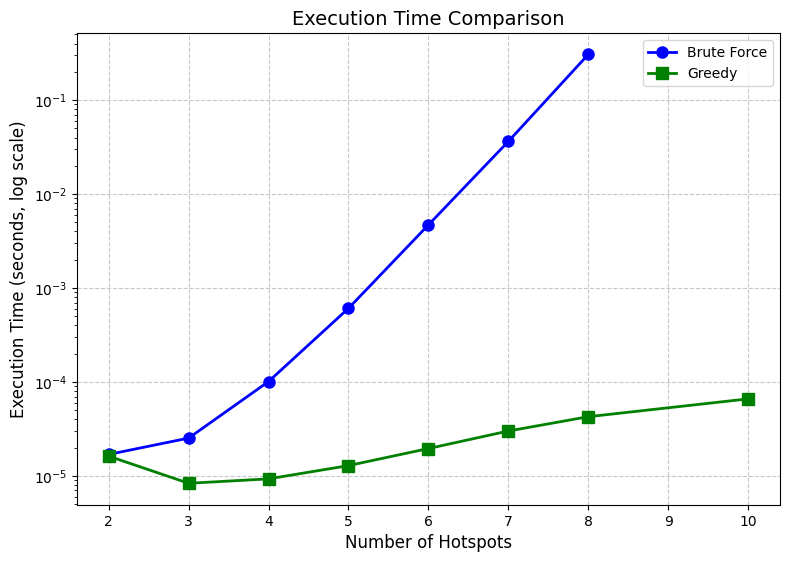

In [ ]:
# Sizes to test - adjust based on your expected range
sizes_to_test = [2, 3, 4, 5, 6, 7, 8, 10]

# Run the comparison test
brute_times, greedy_times, brute_scores, greedy_scores = run_comparison_test(
    hotspots=hotspots,
    battery_capacity=battery_capacity,
    sizes_to_test=sizes_to_test,
    time_limit=300,        # 5 minute overall limit
    timeout_per_test=60    # 1 minute per brute force test
)

# Plot the results
fig = plot_comparison(brute_times, greedy_times, brute_scores, greedy_scores)

The first compares the execution times of the brute force and greedy algorithms. Brute force time grows exponentially, making it infeasible for large hotspot sizes, while the greedy algorithm remains efficient with near-linear scaling.

# Final Conclusion and Reflections
Through this project, I developed a deeper understanding of data preprocessing, model selection, and performance evaluation. I learned how different algorithm implementaions of the same problem present trade-offs between accuracy, interpretability, and complexity. Brute force approaches are not feasible for large amounts of data, whereas the greedy approach is much more scalable.


---

# PART 2

#a) Tabulation Method

The dynamic programming technique of tabulation will be used to solve this 0/1 knapsack-type problem. This approach is optimal because:
- The problem has optimal substructure - the optimal solution can be built from optimal solutions to subproblems
- There are overlapping subproblems - the same calculations would be performed repeatedly in a naive recursive approach
- We need to make binary decisions for each hotspot (include/exclude)

Steps and Logic:
State Definition: Define a 2D-matrix dp[i][j] = maximum priority score achievable by considering the first i hotspots with a total energy budget of j units.

Base Case:
dp[0][j] = 0 for all j, since selecting 0 hotspots gives 0 priority.

Recurrence Relation:
For each hotspot i with ID, priority P, cleaning effort C, and travel energy T:
- Calculate total energy cost E = C + T
- If including the hotspot is feasible (if E ≤ j):
  - We have two choices:
    - Skip hotspot i: dp[i - 1][j]
    - Include hotspot i: dp[i - 1][j - E] + P
  - Take the maximum: dp[i][j] = max(dp[i - 1][j], dp[i - 1][j - E] + P)
- Otherwise (if E > j):
  - dp[i][j] = dp[i - 1][j] (must skip this hotspot)

Table Construction: Create a 2D table of size (n+1) * (battery_capacity+1).
Fill it row by row (bottom-up approach). For each cell, apply the recurrence relation defined above.

Solution Reconstruction: After filling the table, dp[n][battery_capacity] gives the maximum possible priority score.
To determine which hotspots were selected:
- Start at cell (n, battery_capacity)
- For each hotspot i:
  - If j >= energy_cost AND dp[i][j] != dp[i-1][j], then hotspot i was included in the optimal solution
  - If included: add the hotspot's ID (not its index) to our selection list
  - Update j = j - energy_cost for the included hotspot
  - Continue tracing with i-1 and the updated j
- Repeat until i = 0
- Reverse the selection list to restore the original order

Return Values: The maximum priority score (dp[n][battery_capacity]) and the list of selected hotspot IDs that achieve this score.

This approach guarantees finding the optimal subset of hotspots that maximizes the total priority score while keeping the total energy consumption (cleaning effort + travel energy) within the battery capacity budget. The time complexity is O(n * battery_capacity) and the space complexity is O(n * battery_capacity).

#b) Optimal Algorithm Pseudocode

  FUNCTION dynamic_max_priority(hotspots, battery_capacity):

    n = length(hotspots)
   
    // Initialize DP table

    dp[0...n][0...battery_capacity] = 0
   
    // Fill the DP table

    FOR i = 1 TO n:
        (hotspot_id, priority, cleaning, travel) = hotspots[i-1]
        energy_cost = cleaning + travel
       
        FOR j = 0 TO battery_capacity:
            // Default: don't include current hotspot
            dp[i][j] = dp[i-1][j]
           
            // Include current hotspot if possible
            IF j >= energy_cost:
                dp[i][j] = MAX(dp[i][j], dp[i-1][j-energy_cost] + priority)
            END IF
        END FOR
    END FOR
   
    // Reconstruct the selected hotspots
    selected = []
    j = battery_capacity
   
    FOR i = n DOWNTO 1:
        (hotspot_id, priority, cleaning, travel) = hotspots[i-1]
        energy_cost = cleaning + travel
       
        IF dp[i][j] != dp[i-1][j]:
            selected.APPEND(hotspot_id)
            j = j - energy_cost
        END IF
    END FOR
   
    selected.REVERSE()  # Restore original order of selection
   
    RETURN dp[n][battery_capacity], selected
    END FUNCTION

# c) Theoretical Time Complexity

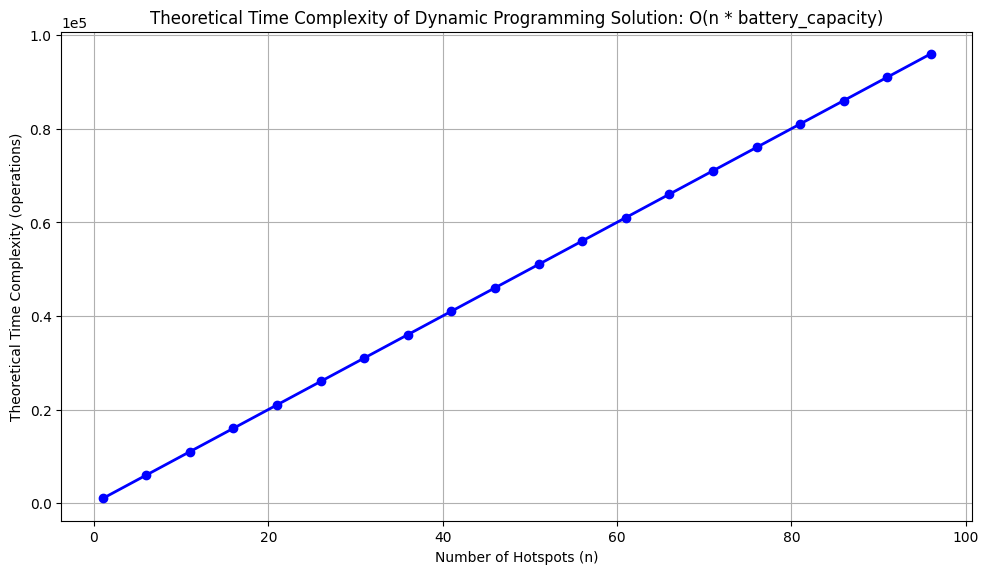

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def plot_theoretical_time_complexity():
    # Define the range of hotspots to analyze
    # Using increments of 5 from 1 to 100 for better visualization
    n_values = np.arange(1, 101, 5)

    # Define the fixed battery capacity (in units of energy)
    # This represents the maximum energy available for the drone
    battery_capacity = 1000

    # Calculate the theoretical time complexity for each number of hotspots
    # Time complexity is O(n * battery_capacity) where:
    #   - n is the number of hotspots
    #   - battery_capacity is constant for this analysis
    # Since battery_capacity is fixed, the growth rate is effectively O(n)
    complexity = [n * battery_capacity for n in n_values]

    # Create visualization
    plt.figure(figsize=(10, 6))  # Set figure size for better readability

    # Plot the complexity curve with blue line, markers at data points
    plt.plot(n_values, complexity, 'b-', linewidth=2, marker='o')

    # Add descriptive labels and title
    plt.xlabel('Number of Hotspots (n)')
    plt.ylabel('Theoretical Time Complexity (operations)')
    plt.title('Theoretical Time Complexity of Dynamic Programming Solution: O(n * battery_capacity)')

    # Add grid for easier reading of values
    plt.grid(True)

    # Format y-axis using scientific notation for larger numbers
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

    # Adjust layout to prevent clipping of labels
    plt.tight_layout()

    # Display the plot
    plt.show()

# Execute the function to generate and display the plot
plot_theoretical_time_complexity()

#d) Implementation of Optimal Solution using Tabulation


In [15]:
def dynamic_max_priority(hotspots, battery_capacity):
    """
    Solves the knapsack problem to find the maximum priority hotspots to clean within battery constraints.

    Args:
        hotspots: List of tuples, each containing (id, priority, cleaning_energy, travel_energy)
        battery_capacity: Maximum energy available for the drone

    Returns:
        tuple: (maximum_priority_achievable, list_of_selected_hotspot_ids)
    """
    n = len(hotspots)  # Number of hotspots to consider

    # Initialize dynamic programming table:
    # - Rows (i): Number of hotspots considered (0 to n)
    # - Columns (j): Available energy (0 to battery_capacity)
    # - Cell value dp[i][j]: Maximum priority achievable considering first i hotspots with j energy
    dp = [[0] * (battery_capacity + 1) for _ in range(n + 1)]

    # Fill the DP table bottom-up
    for i in range(1, n + 1):
        # Get current hotspot details (using 0-based indexing for the hotspots list)
        hotspot_id, priority, cleaning, travel = hotspots[i-1]
        energy_cost = cleaning + travel  # Total energy needed for this hotspot

        # For each possible energy availability level
        for j in range(battery_capacity + 1):
            if energy_cost > j:
                # If this hotspot requires more energy than available, skip it
                dp[i][j] = dp[i-1][j]  # Take solution without this hotspot
            else:
                # Choose better option between:
                # 1. Skip this hotspot: take previous solution (dp[i-1][j])
                # 2. Take this hotspot: add its priority to best solution with remaining energy
                dp[i][j] = max(dp[i-1][j], dp[i-1][j - energy_cost] + priority)

    # Backtrack to find which hotspots were selected
    selected = []
    i, j = n, battery_capacity  # Start from bottom-right cell of DP table

    # Work backwards through the table
    while i > 0 and j > 0:
        hotspot_id, priority, cleaning, travel = hotspots[i-1]
        energy_cost = cleaning + travel

        # If current solution includes this hotspot (value changed from previous row)
        if j >= energy_cost and dp[i][j] != dp[i-1][j]:
            selected.append(hotspot_id)  # Add hotspot to selection
            j -= energy_cost  # Reduce available energy
        i -= 1  # Move to previous hotspot

    # Reverse to get chronological order of selection
    selected.reverse()

    # Return maximum achievable priority and the list of selected hotspot IDs
    return dp[n][battery_capacity], selected

#e) Performance Test

In [16]:
import time

# Start timing the execution of the algorithm
start_time = time.time()

# Run the dynamic programming algorithm to find optimal hotspots
max_priority, selected_ids = dynamic_max_priority(hotspots, battery_capacity)

# End timing and calculate duration
end_time = time.time()
execution_time = end_time - start_time

# Display the results of the algorithm
print(f"Max Priority Score: {max_priority}")
print(f"Selected Hotspot IDs: {selected_ids}")
print(f"Execution Time: {execution_time:.6f} seconds")  # Format to 6 decimal places

Max Priority Score: 1949
Selected Hotspot IDs: [2, 11, 15, 17, 22, 28, 31, 33, 37, 39, 45, 48, 51, 57, 62, 68, 69, 71, 77, 81, 82, 85, 89, 91, 97]
Execution Time: 0.032716 seconds


#f) Practical Time Complexity

Size 10: 0.002721 seconds
Size 20: 0.004963 seconds
Size 30: 0.008644 seconds
Size 40: 0.010678 seconds
Size 50: 0.012939 seconds
Size 60: 0.015777 seconds
Size 70: 0.018112 seconds
Size 80: 0.021672 seconds
Size 90: 0.023374 seconds
Size 100: 0.027545 seconds


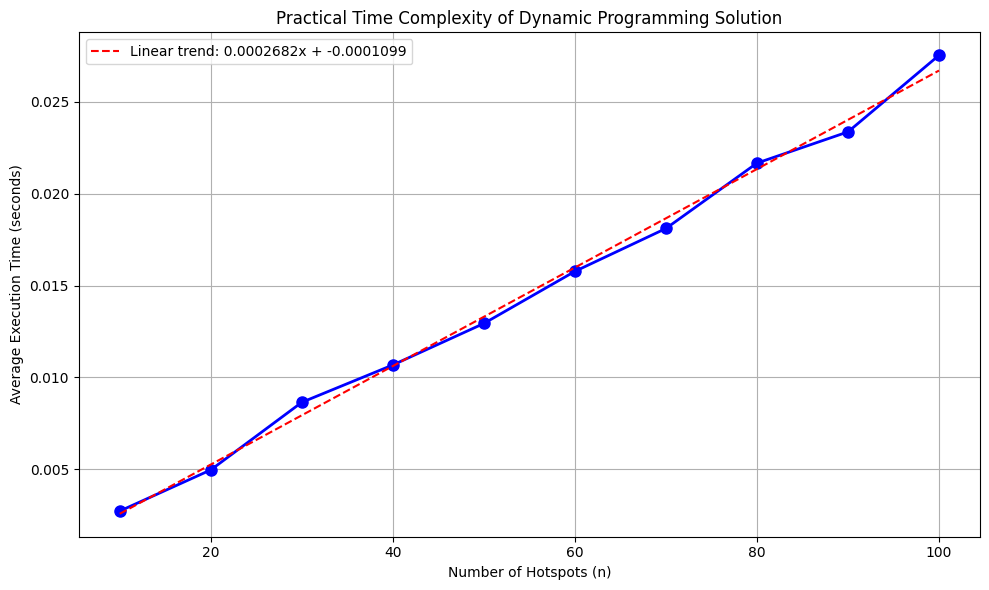

In [18]:
import time
import numpy as np
import matplotlib.pyplot as plt

# Parameters
sizes = list(range(10, 101, 10))  # Test with different numbers of hotspots (10-100)
repeats = 15  # Number of runs to average for more reliable measurements
times = []

for size in sizes:
   total_time = 0
   subset = hotspots[:size]  # Use only the first 'size' hotspots from the dataset

   # Run algorithm multiple times and measure execution time
   for _ in range(repeats):
       start = time.perf_counter()  # More precise timer than time.time()
       _ = dynamic_max_priority(subset, battery_capacity)  # Run algorithm, discard results
       end = time.perf_counter()
       total_time += (end - start)

   # Calculate and store average execution time
   avg_time = total_time / repeats
   times.append(avg_time)
   print(f"Size {size}: {avg_time:.6f} seconds")

# Create visualization
plt.figure(figsize=(10, 6))

# Plot measured times with blue markers and lines
plt.plot(sizes, times, 'bo-', linewidth=2, markersize=8)

# Calculate and add linear trend line to confirm O(n) behavior
z = np.polyfit(sizes, times, 1)  # Linear regression
p = np.poly1d(z)  # Create polynomial function from coefficients
plt.plot(sizes, p(sizes), "r--",
        label=f'Linear trend: {z[0]:.7f}x + {z[1]:.7f}')  # Show equation on legend

# Add labels and formatting
plt.title('Practical Time Complexity of Dynamic Programming Solution')
plt.xlabel('Number of Hotspots (n)')
plt.ylabel('Average Execution Time (seconds)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#g) Comparisons and Conclusion

##Brute Force Approach
- Time complexity: O(2^n * n!)
- Space complexity: O(2^n * n)
- While this approach yields an optimal solution, it is infeasible for a large set of hotspots.

##Greedy Approach
- Time complexity: O(nlogn)
- Space complexity: O(n)
- While this approach is feasible for large datasets and provides a quick solution, it does not yield an optimal solution.

## Dynamic Approach using Tabulation
- Time complexity: O(n * battery_capacity)
- Space complexity: O(n * battery_capacity)
- So, the dynamic approach yields an optimal solution and is feasible for moderate-sized datasets.

After analyzing the three approaches for solving the drone hotspot cleaning optimization problem, I've determined that each method offers distinct trade-offs. The brute force approach guarantees optimal solutions but becomes computationally infeasible with its exponential complexity. The greedy approach provides extremely efficient solutions but sacrifices optimality. The dynamic programming approach strikes an excellent balance by delivering optimal solutions with reasonable O(n * battery_capacity) complexity, making it practical for real-world deployment scenarios.
My empirical testing confirmed the theoretical complexity analysis, showing that the dynamic programming approach scales linearly with the number of hotspots when battery capacity remains constant. This makes it the recommended choice for drone navigation systems where maximizing priority scores within energy constraints is critical. The tabulation method's ability to guarantee optimality while maintaining computational efficiency represents the ideal solution for this class of resource-constrained optimization problems.